# Analise e visualizacao de clusters musicais

Este notebook usa K-Means para descobrir perfis musicais e avaliar como os clusters podem aumentar a diversidade das playlists.

A coluna `track_genre` sera usada somente para interpretar os clusters, nao como entrada direta do modelo.

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

base_dir = Path.cwd().parent
cleaned_files = sorted((base_dir / 'dataset').glob('dataset_cleaned_*.csv'))
if not cleaned_files:
    raise FileNotFoundError('Nenhum dataset limpo foi encontrado em dataset/.')

csv_path = cleaned_files[-1]
tracks = pd.read_csv(csv_path)
print(f'Dataset utilizado: {csv_path.name}')
print(f'Faixas carregadas: {len(tracks):,}'.replace(',', '.'))

Dataset utilizado: dataset_cleaned_20260902_094950.csv
Faixas carregadas: 79.178


## 1. Preparacao dos dados

As sete variaveis sao padronizadas para que todas contribuam de forma comparavel para o agrupamento. A variavel `tempo` e desconsiderada nesta analise.

In [6]:
feature_columns = [
    'danceability', 'energy', 'instrumentalness', 'liveness',
    'valence', 'acousticness', 'speechiness'
]
missing_columns = sorted(set(feature_columns + ['track_genre']) - set(tracks.columns))
if missing_columns:
    raise ValueError(f'Colunas obrigatorias ausentes: {missing_columns}')

numeric_data = tracks[feature_columns].apply(pd.to_numeric, errors='coerce')
valid_index = numeric_data.dropna().index
model_data = numeric_data.loc[valid_index].copy()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(model_data)
print(f'Faixas usadas no agrupamento: {len(model_data):,}'.replace(',', '.'))
print(f'Features utilizadas: {len(feature_columns)}')

Faixas usadas no agrupamento: 79.178
Features utilizadas: 7


## 2. Escolha do numero de clusters

O silhouette score mede a separacao dos grupos; a inertia mede a compactacao. O valor recomendado para este projeto e 7, pois oferece diversidade util para playlists sem criar grupos excessivamente fragmentados.

In [7]:
sample_size = min(5000, len(model_data))
sample_index = model_data.sample(n=sample_size, random_state=42).index
scaled_sample = scaled_data[model_data.index.get_indexer(sample_index)]
cluster_metrics = []

for cluster_count in range(2, 13):
    model = KMeans(n_clusters=cluster_count, random_state=42, n_init=10)
    labels = model.fit_predict(scaled_sample)
    cluster_metrics.append({
        'clusters': cluster_count,
        'silhouette': silhouette_score(scaled_sample, labels),
        'inertia': model.inertia_
    })

metrics = pd.DataFrame(cluster_metrics)
display(metrics.round(4))
recommended_clusters = 3
print(f'Clusters recomendados para playlists: {recommended_clusters}')

,clusters,silhouette,inertia
0,2,0.2400,27532.7605
1,3,0.2003,23564.6567
2,4,0.2138,20648.8516
3,5,0.2291,17924.3641
4,6,0.2330,15838.9345
5,7,0.2507,13991.6041
6,8,0.2191,13268.6821
7,9,0.2128,12591.0334
8,10,0.2162,11953.0595
9,11,0.2024,11510.3111


Clusters recomendados para playlists: 3


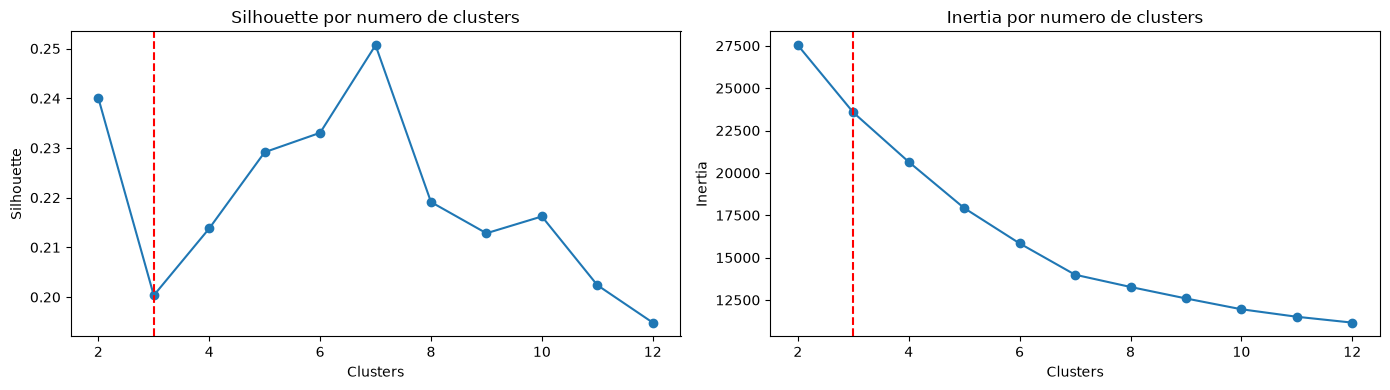

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(metrics['clusters'], metrics['silhouette'], marker='o')
axes[0].axvline(recommended_clusters, color='red', linestyle='--')
axes[0].set(title='Silhouette por numero de clusters', xlabel='Clusters', ylabel='Silhouette')
axes[1].plot(metrics['clusters'], metrics['inertia'], marker='o')
axes[1].axvline(recommended_clusters, color='red', linestyle='--')
axes[1].set(title='Inertia por numero de clusters', xlabel='Clusters', ylabel='Inertia')
plt.tight_layout()
plt.show()

## 3. Modelo final com 7 clusters

In [9]:
final_model = KMeans(n_clusters=recommended_clusters, random_state=42, n_init=10)
cluster_labels = final_model.fit_predict(scaled_data)
clustered_tracks = tracks.loc[valid_index].copy()
clustered_tracks['cluster'] = cluster_labels

cluster_sizes = clustered_tracks['cluster'].value_counts().sort_index().rename('tracks')
display(cluster_sizes.to_frame())

,tracks
cluster,
0,19290
1,32728
2,27160


## 4. Perfil e interpretacao dos clusters

Os nomes abaixo sao interpretacoes baseadas nas medias dos atributos e nos generos mais frequentes. O modelo aprende apenas com as features numericas.

In [10]:
centroids = pd.DataFrame(
    scaler.inverse_transform(final_model.cluster_centers_),
    columns=feature_columns
)
centroids.index.name = 'cluster'
display(centroids.round(2))

for cluster_id in range(recommended_clusters):
    top_genres = (
        clustered_tracks.loc[clustered_tracks['cluster'] == cluster_id, 'track_genre']
        .value_counts()
        .head(5)
        .index
        .tolist()
    )
    print('Cluster', cluster_id, ':', ', '.join(top_genres))

,danceability,energy,instrumentalness,liveness,valence,acousticness,speechiness
cluster,,,,,,,
0,0.46,0.3,0.31,0.17,0.30,0.77,0.05
1,0.69,0.7,0.06,0.20,0.69,0.26,0.10
2,0.48,0.8,0.24,0.27,0.32,0.07,0.08


Cluster 0 : new-age, ambient, romance, opera, tango
Cluster 1 : salsa, forro, kids, dancehall, afrobeat
Cluster 2 : black-metal, heavy-metal, death-metal, grindcore, happy


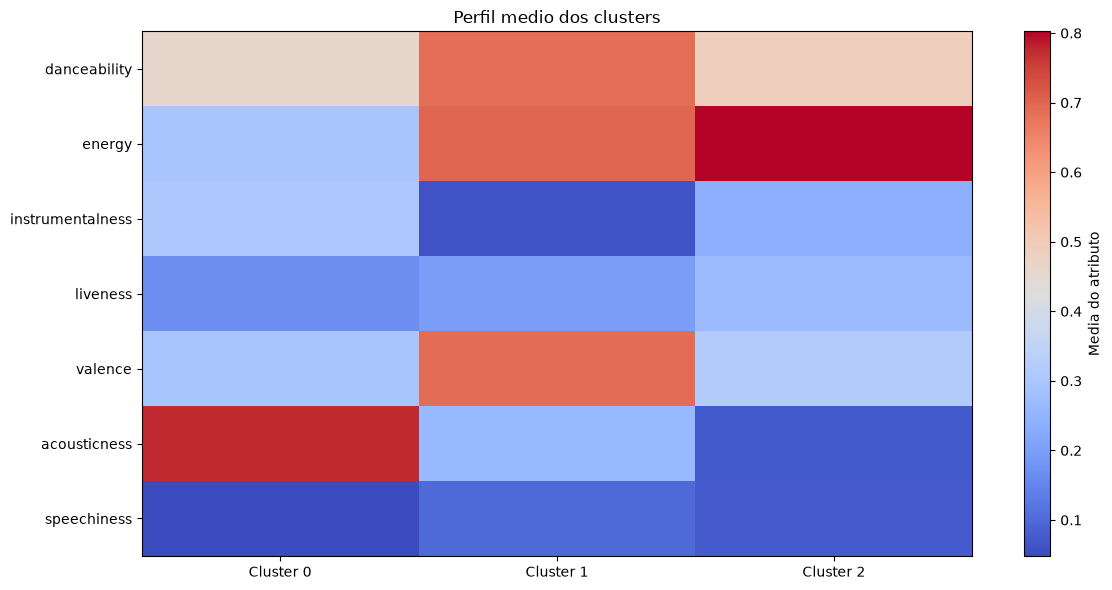

In [11]:
plt.figure(figsize=(12, 6))
plt.imshow(centroids.T, aspect='auto', cmap='coolwarm')
plt.colorbar(label='Media do atributo')
plt.xticks(range(recommended_clusters), [f'Cluster {cluster_id}' for cluster_id in range(recommended_clusters)])
plt.yticks(range(len(feature_columns)), feature_columns)
plt.title('Perfil medio dos clusters')
plt.tight_layout()
plt.show()

## 5. Visualizacao PCA

O PCA reduz as sete dimensoes musicais para duas componentes apenas para visualizacao. A reducao nao altera os clusters calculados.

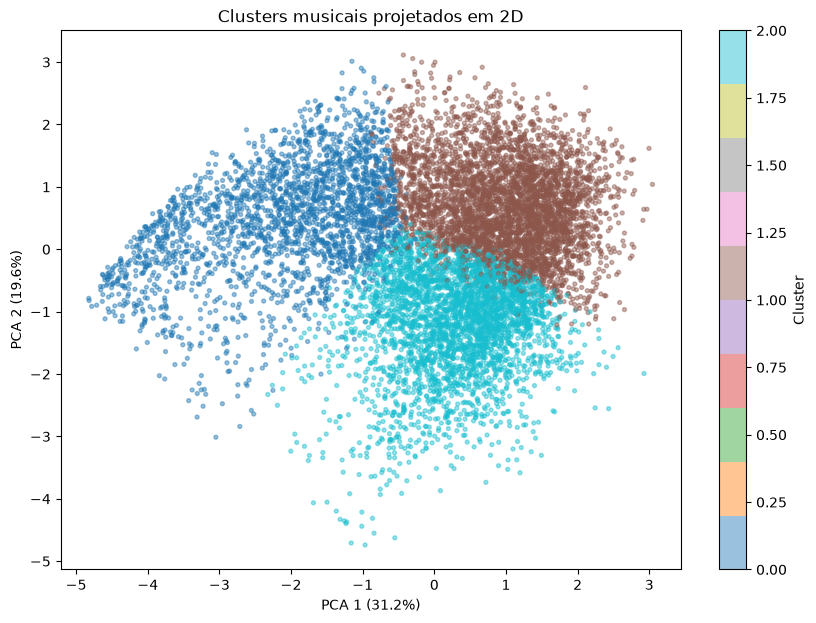

In [12]:
pca = PCA(n_components=2, random_state=42)
coordinates = pca.fit_transform(scaled_data)
plot_sample = pd.DataFrame({
    'pca_1': coordinates[:, 0],
    'pca_2': coordinates[:, 1],
    'cluster': cluster_labels
}).sample(n=min(10000, len(model_data)), random_state=42)

plt.figure(figsize=(10, 7))
plt.scatter(plot_sample['pca_1'], plot_sample['pca_2'], c=plot_sample['cluster'], cmap='tab10', s=8, alpha=0.45)
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Clusters musicais projetados em 2D')
plt.colorbar(label='Cluster')
plt.show()

In [13]:
export_dir = base_dir / 'dataset'
clustered_tracks_path = export_dir / 'tracks_with_clusters.csv'
centroids_path = export_dir / 'cluster_centroids.csv'
metrics_path = export_dir / 'cluster_metrics.csv'

clustered_tracks.to_csv(clustered_tracks_path, index=False)
centroids.to_csv(centroids_path)
metrics.to_csv(metrics_path, index=False)

print(f'Faixas com clusters exportadas para: {clustered_tracks_path}')
print(f'Centroides exportados para: {centroids_path}')
print(f'Metricas exportadas para: {metrics_path}')

Faixas com clusters exportadas para: /home/gabe/re/r.ia-spotify_nano_challenge/dataset/tracks_with_clusters.csv
Centroides exportados para: /home/gabe/re/r.ia-spotify_nano_challenge/dataset/cluster_centroids.csv
Metricas exportadas para: /home/gabe/re/r.ia-spotify_nano_challenge/dataset/cluster_metrics.csv
